In [40]:
# Import the necessary dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Import the performance metrics and model selection tools
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import different models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor  
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from prophet import Prophet

from statsmodels.stats.stattools import durbin_watson

import warnings
warnings.filterwarnings('ignore')

## Data Ingestion

In [25]:
# File path 
file_path = r"data\raw\retail_sales_dataset.csv"

df = pd.read_csv(file_path)

In [26]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.isnull().sum().sum() ## Check for the total sum of missing values

np.int64(0)

In [27]:
# Change the data type of the 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [9]:
## Select only the columns needed for the time series analysis
## df.columns

#cols_to_use = ["Date", "Customer ID", "Product Category", "Quantity", "Price per Unit", "Total Amount"]
#df = df[cols_to_use]
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [10]:
# Check for how many unique product categories that we have in the dataset
# df['Product Category'].nunique()
df["Product Category"].value_counts(normalize=True) *100

Product Category
Clothing       35.1
Electronics    34.2
Beauty         30.7
Name: proportion, dtype: float64

In [11]:
import plotly.io as pio
pio.renderers.default = 'plotly_mimetype'

In [12]:
# Create an interactive scatter plot using Plotly
fig = px.scatter(df, x='Age', y='Total Amount', title='Scatterplot of Age vs. Total Amount', labels={'Age': 'Age', 'Total Amount': 'Total Amount'})

# Update hover information to display x and y values
fig.update_traces(marker=dict(size=10),
                  selector=dict(mode='markers+text'),
                  texttemplate='%{x}, %{y}')

# Show the plot
fig.show()

In [13]:
# Create an interactive histogram
fig = px.histogram(df, x='Gender', title='Histogram of Gender', labels={'Gender': 'Gender', 'count': 'Frequency'})

# Update hover information to display frequency values
fig.update_traces(texttemplate='%{y}', textposition='outside')

# Show the plot
fig.show()

In [14]:
# Create an interactive histogram
fig = px.histogram(df, x='Product Category', title='Histogram of Product Category', labels={'Product Category': 'Product Category', 'count': 'Frequency'})

# Update hover information to display frequency values
fig.update_traces(texttemplate='%{y}', textposition='outside')

# Show the plot
fig.show()

### Examining The Time Series Data

In [17]:
# Set the 'Date' column as the index
#df.set_index('Date', inplace=True)

# Resample data by month and sum the 'Total Amount' per month
monthly_sales = df.resample('ME').sum()

# Create an interactive time series plot for Monthly Total Amount
fig = px.line(monthly_sales, x=monthly_sales.index, y='Total Amount', title='Monthly Total Amount')
fig.update_xaxes(title_text='Date (Monthly)')
fig.update_yaxes(title_text='Total Amount')

# Add hover-over values with the date
fig.update_traces(mode='lines+markers', hovertemplate='%{y:.2f} USD<br>%{x|%Y-%m}')

# Show the plot
fig.show()

In [18]:
## Weekly Total Amount

# Resample data by week and sum the 'Total Amount' per week
weekly_sales = df.resample('W').sum()

# Create an interactive time series plot for Weekly Total Amount
fig = px.line(weekly_sales, x=weekly_sales.index, y='Total Amount', title='Weekly Total Amount')
fig.update_xaxes(title_text='Date (Weekly)')
fig.update_yaxes(title_text='Total Amount')

# Add hover-over values with the date
fig.update_traces(mode='lines+markers', hovertemplate='%{y:.2f} USD<br>%{x|%Y-%m-%d}')

# Show the plot
fig.show()

In [19]:
### Daily Total Amount

# Resample data by day and sum the 'Total Amount' per day
daily_sales = df.resample('D').sum()

# Create an interactive time series plot for Daily Total Amount
fig = px.line(daily_sales, x=daily_sales.index, y='Total Amount', title='Daily Total Amount')
fig.update_xaxes(title_text='Date (Daily)')
fig.update_yaxes(title_text='Total Amount')

# Add hover-over values with the date
fig.update_traces(mode='lines+markers', hovertemplate='%{y:.2f} USD<br>%{x|%Y-%m-%d}')

# Show the plot
fig.show()

## Creating a Baseline Model

In [22]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Gender', 'Age', 'Product Category',
       'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [28]:
df = df.reset_index(drop=True)

# Now apply one-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = encoder.fit_transform(df[['Product Category']])

# Create DataFrame with encoded columns
encoded_df = pd.DataFrame(
    encoded_cats, 
    columns=encoder.get_feature_names_out(['Product Category'])
)

# Concatenate with original dataframe
df_encoded = pd.concat([df.drop('Product Category', axis=1), encoded_df], axis=1)
df_encoded.head()

,Transaction ID,Date,Customer ID,Gender,Age,Quantity,Price per Unit,Total Amount,Product Category_Beauty,Product Category_Clothing,Product Category_Electronics
0,1,2023-11-24,CUST001,Male,34,3,50,150,1.0,0.0,0.0
1,2,2023-02-27,CUST002,Female,26,2,500,1000,0.0,1.0,0.0
2,3,2023-01-13,CUST003,Male,50,1,30,30,0.0,0.0,1.0
3,4,2023-05-21,CUST004,Male,37,1,500,500,0.0,1.0,0.0
4,5,2023-05-06,CUST005,Male,30,2,50,100,1.0,0.0,0.0


Here wwe will consider `Age, Quantity and Price Per Unit` columns for the model craetion

In [29]:
# Creating train/test split
X = df[['Age', 'Quantity', 'Price per Unit']]
y = df['Total Amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating model
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared (R2) Score: {r2}")

# Create a DataFrame for visualization
df = pd.DataFrame({'True Values': y_test, 'Predictions': y_pred})

# Create a scatter plot using Plotly Express
fig = px.scatter(df, x='True Values', y='Predictions', title='True vs. Predicted Values')
fig.update_traces(marker=dict(size=10, opacity=0.5, line=dict(width=2, color='black')))

# Add hover data (x and y coordinates)
fig.update_traces(customdata=df.index)

# Customize the hover tooltip
fig.update_traces(hovertemplate='True Value: %{x}<br>Predicted Value: %{y}<br>Sample Index: %{customdata}')

# Add a trendline (optional)
fig.add_trace(go.Scatter(x=df['True Values'], y=df['True Values'], mode='lines', name='Trendline'))

# Customize the layout
fig.update_layout(
    xaxis_title="True Values",
    yaxis_title="Predictions"
)

# Show the interactive plot in the Jupyter Notebook
fig.show()

Mean Squared Error: 41896.213221343576
Root Mean Squared Error: 204.68564488342503
R-squared (R2) Score: 0.8568772264250432


In [30]:
df_encoded.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Quantity',
       'Price per Unit', 'Total Amount', 'Product Category_Beauty',
       'Product Category_Clothing', 'Product Category_Electronics'],
      dtype='str')

The above doesnt work since this is a time series forecast and there is no need for a random split, thus, we make use of a quantile or percentile split here and also change the columns to accomodate the columns that we alreadyu have here in our production system.

Here we cosnider other columns from the Product Category

Mean Squared Error: 41913.53518382583
Root Mean Squared Error: 204.72795408499013
R-squared (R2) Score: 0.856818052406114


In [33]:
df_encoded = df_encoded.sort_values('Date').reset_index(drop=True)

# Define features and target
feature_cols = ['Age', 'Quantity', 'Price per Unit', 
                'Product Category_Beauty', 'Product Category_Clothing', 
                'Product Category_Electronics']

X = df_encoded[feature_cols]
y = df_encoded['Total Amount']

# Time-based split (80% train, 20% test)
split_point = int(len(df_encoded) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print(f"Training period: {df_encoded['Date'].iloc[0]} to {df_encoded['Date'].iloc[split_point-1]}")
print(f"Testing period: {df_encoded['Date'].iloc[split_point]} to {df_encoded['Date'].iloc[-1]}")
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Create results dataframe with dates for better visualization
results_df = pd.DataFrame({
    'Date': df_encoded['Date'].iloc[split_point:].values,
    'True Values': y_test.values,
    'Predictions': y_pred,
    'Residuals': y_test.values - y_pred
})

# Plot actual vs predicted over time
fig = go.Figure()

# Add actual values
fig.add_trace(go.Scatter(
    x=results_df['Date'], 
    y=results_df['True Values'],
    mode='lines+markers',
    name='Actual',
    line=dict(color='blue', width=2)
))

# Add predicted values
fig.add_trace(go.Scatter(
    x=results_df['Date'], 
    y=results_df['Predictions'],
    mode='lines+markers',
    name='Predicted',
    line=dict(color='red', width=2, dash='dash')
))

fig.update_layout(
    title=f'Time Series Forecast (Test Period: {results_df["Date"].iloc[0]} to {results_df["Date"].iloc[-1]})',
    xaxis_title='Date',
    yaxis_title='Total Amount',
    hovermode='x unified'
)

fig.show()

# Also show scatter plot for comparison
scatter_fig = px.scatter(
    results_df, 
    x='True Values', 
    y='Predictions',
    title=f'Actual vs Predicted (R² = {r2:.4f})',
    hover_data={'Date': True}
)

# Add perfect prediction line
min_val = min(results_df['True Values'].min(), results_df['Predictions'].min())
max_val = max(results_df['True Values'].max(), results_df['Predictions'].max())
scatter_fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red', dash='dash')
))

scatter_fig.show()

# Check for autocorrelation in residuals (important for time series)
dw = durbin_watson(results_df['Residuals'])
print(f"\nDurbin-Watson statistic: {dw:.4f}")
print("(Values close to 2 indicate no autocorrelation)")

Training period: 2023-01-01 00:00:00 to 2023-10-21 00:00:00
Testing period: 2023-10-22 00:00:00 to 2024-01-01 00:00:00
Training samples: 800, Testing samples: 200

Model Performance:
MSE: 39164.46
RMSE: 197.90
R² Score: 0.8816



Durbin-Watson statistic: 2.1116
(Values close to 2 indicate no autocorrelation)


Now, we experiment with more machine learning algorithms and see what outcomes we happen to get on this voyage. Whatever the result is will be improved upon before we commence our building of the production script hence.

### Integrating FaceBook Prophet alongside Other Algorithms for Model craetion

We'll eventually select the best 3 with their hyperparameters for building te production file

Training period: 2023-01-01 00:00:00 to 2023-10-21 00:00:00
Testing period: 2023-10-22 00:00:00 to 2024-01-01 00:00:00
Training samples: 800, Testing samples: 200

Training Prophet...


14:22:40 - cmdstanpy - INFO - Chain [1] start processing
14:23:17 - cmdstanpy - INFO - Chain [1] done processing


  ✓ R² Score: -6.9677, RMSE: 1623.29
Training Linear Regression...
  ✓ R² Score: 0.8816, RMSE: 197.90
Training Ridge Regression...
  ✓ R² Score: 0.8815, RMSE: 197.96
Training Lasso Regression...
  ✓ R² Score: 0.8816, RMSE: 197.90
Training Decision Tree...
  ✓ R² Score: 1.0000, RMSE: 0.00
Training Random Forest...
  ✓ R² Score: 1.0000, RMSE: 0.00
Training Gradient Boosting...
  ✓ R² Score: 1.0000, RMSE: 0.02
Training KNN...
  ✓ R² Score: 0.9955, RMSE: 38.66
Training SVR...
  ✓ R² Score: 0.9910, RMSE: 54.44

MODEL PERFORMANCE COMPARISON
            Model          MSE      RMSE       MAE      R2  Durbin-Watson
    Decision Tree       0.0000    0.0000    0.0000  1.0000            NaN
    Random Forest       0.0000    0.0000    0.0000  1.0000            NaN
Gradient Boosting       0.0002    0.0153    0.0126  1.0000         2.1140
              KNN    1494.4600   38.6582   24.0700  0.9955         2.1308
              SVR    2963.9193   54.4419   24.0415  0.9910         2.0978
Linear Regressi

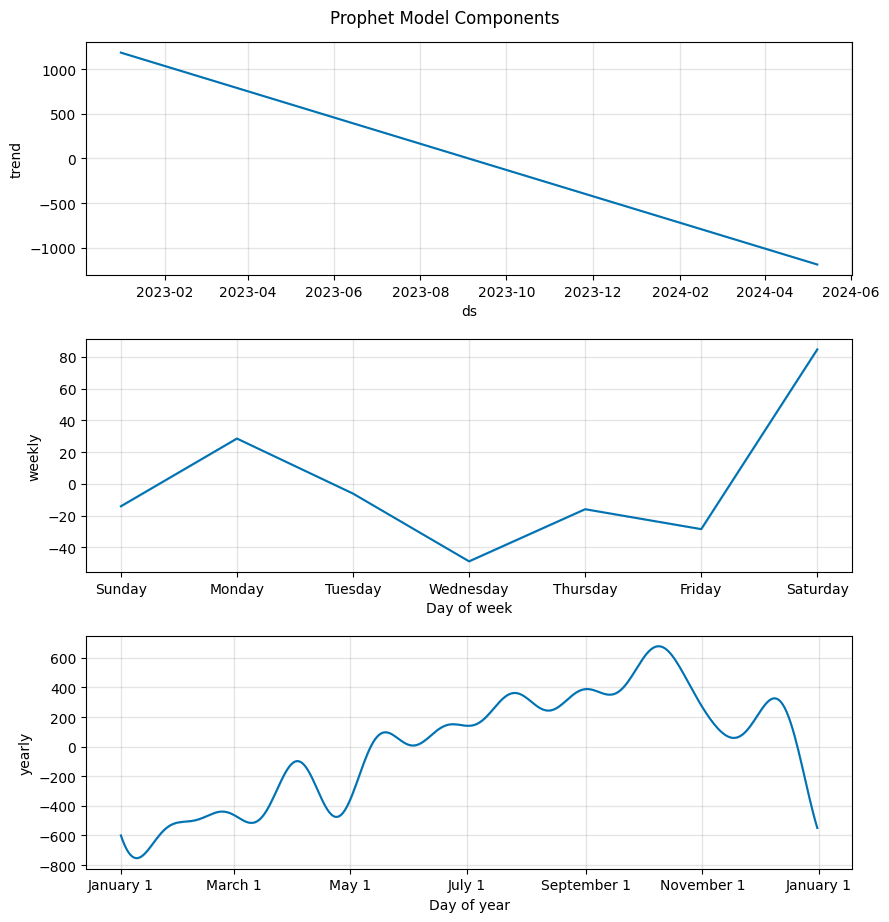


PROPHET MODEL DIAGNOSTICS
MAPE: 1096.54%
Residual normality test (Shapiro-Wilk) p-value: 0.0000
(p-value > 0.05 suggests residuals are normally distributed)


In [39]:
df_encoded = df_encoded.sort_values('Date').reset_index(drop=True)

# Define features and target
feature_cols = ['Age', 'Quantity', 'Price per Unit', 
                'Product Category_Beauty', 'Product Category_Clothing', 
                'Product Category_Electronics']

X = df_encoded[feature_cols]
y = df_encoded['Total Amount']

split_point = int(len(df_encoded) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print(f"Training period: {df_encoded['Date'].iloc[0]} to {df_encoded['Date'].iloc[split_point-1]}")
print(f"Testing period: {df_encoded['Date'].iloc[split_point]} to {df_encoded['Date'].iloc[-1]}")
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}\n")

# Prophet requires a specific format: 'ds' for dates, 'y' for target
prophet_train = pd.DataFrame({
    'ds': df_encoded['Date'].iloc[:split_point],
    'y': y_train.values
})

prophet_test_dates = df_encoded['Date'].iloc[split_point:]

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
}

# For models that need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []
predictions = {}

# First, handle Prophet separately
print("Training Prophet...")

try:
    prophet_model = Prophet(
        interval_width=0.95,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='additive'
    )
    
    # Fit Prophet model
    prophet_model.fit(prophet_train)
    
    # Create future dataframe for test period
    future = prophet_model.make_future_dataframe(
        periods=len(prophet_test_dates),
        include_history=False
    )
    
    # Make predictions
    prophet_forecast = prophet_model.predict(future)
    y_pred_prophet = prophet_forecast['yhat'].values
    
    # Store predictions
    predictions['Prophet'] = y_pred_prophet
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred_prophet)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_prophet)
    r2 = r2_score(y_test, y_pred_prophet)
    residuals = y_test.values - y_pred_prophet
    dw = durbin_watson(residuals)
    
    results.append({
        'Model': 'Prophet',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Durbin-Watson': dw
    })
    
    print(f"  ✓ R² Score: {r2:.4f}, RMSE: {rmse:.2f}")
    
except Exception as e:
    print(f"  ✗ Prophet Error: {str(e)[:100]}...")
    results.append({
        'Model': 'Prophet',
        'MSE': np.nan,
        'RMSE': np.nan,
        'MAE': np.nan,
        'R2': np.nan,
        'Durbin-Watson': np.nan
    })

# Now train all other models
for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Check if model needs scaled data
    if model_name in ['SVR', 'KNN', 'Ridge Regression', 'Lasso Regression']:
        X_train_used = X_train_scaled
        X_test_used = X_test_scaled
    else:
        X_train_used = X_train
        X_test_used = X_test
    
    try:
        # Train model
        model.fit(X_train_used, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_used)
        predictions[model_name] = y_pred
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        residuals = y_test.values - y_pred
        dw = durbin_watson(residuals)
        
        results.append({
            'Model': model_name,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'Durbin-Watson': dw
        })
        
        print(f"  ✓ R² Score: {r2:.4f}, RMSE: {rmse:.2f}")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:50]}...")
        results.append({
            'Model': model_name,
            'MSE': np.nan,
            'RMSE': np.nan,
            'MAE': np.nan,
            'R2': np.nan,
            'Durbin-Watson': np.nan
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).round(4)
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Find best model
best_model = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2']
print(f"\n🏆 Best Model: {best_model} (R² = {best_r2:.4f})")

if 'Prophet' in predictions and not np.isnan(results_df[results_df['Model']=='Prophet']['R2'].values[0]):
    
    # Get the full forecast (including training period) for visualization
    future_with_history = prophet_model.make_future_dataframe(periods=len(prophet_test_dates))
    full_forecast = prophet_model.predict(future_with_history)
    
    # 1. Plot Prophet forecast components
    fig_prophet_components = prophet_model.plot_components(full_forecast)
    fig_prophet_components.suptitle('Prophet Model Components', y=1.02)
    plt.show()
    
    # 2. Create interactive Plotly forecast visualization
    fig_prophet = go.Figure()
    
    # Training data
    fig_prophet.add_trace(go.Scatter(
        x=prophet_train['ds'],
        y=prophet_train['y'],
        mode='markers',
        name='Training Data',
        marker=dict(color='blue', size=4, opacity=0.5)
    ))
    
    # Test actual values
    fig_prophet.add_trace(go.Scatter(
        x=prophet_test_dates,
        y=y_test,
        mode='markers+lines',
        name='Actual (Test)',
        marker=dict(color='green', size=8),
        line=dict(color='green', width=2)
    ))
    
    # Prophet predictions
    fig_prophet.add_trace(go.Scatter(
        x=prophet_test_dates,
        y=predictions['Prophet'],
        mode='lines+markers',
        name='Prophet Forecast',
        line=dict(color='red', width=3),
        marker=dict(color='red', size=6)
    ))
    
    # Add uncertainty intervals from Prophet
    fig_prophet.add_trace(go.Scatter(
        x=pd.concat([prophet_test_dates, prophet_test_dates[::-1]]),
        y=pd.concat([prophet_forecast['yhat_upper'], prophet_forecast['yhat_lower'][::-1]]),
        fill='toself',
        fillcolor='rgba(255,0,0,0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        name='95% Prediction Interval'
    ))
    
    fig_prophet.update_layout(
        title='Prophet Forecast vs Actual',
        xaxis_title='Date',
        yaxis_title='Total Amount',
        hovermode='x unified',
        height=500
    )
    fig_prophet.show()

# 1. Bar chart comparing model performance
fig1 = px.bar(results_df.sort_values('R2'), 
              x='Model', 
              y='R2',
              title='Model Performance Comparison (R² Score)',
              color='R2',
              color_continuous_scale='viridis',
              text='R2')

fig1.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig1.update_layout(xaxis_tickangle=-45, height=500)
fig1.show()

# 2. Compare top 3 models vs actual values
top_3_models = results_df.head(3)['Model'].tolist()

fig2 = go.Figure()

# Add actual values
fig2.add_trace(go.Scatter(
    x=df_encoded['Date'].iloc[split_point:],
    y=y_test,
    mode='lines+markers',
    name='Actual',
    line=dict(color='black', width=3)
))

# Add predictions from top models
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, model_name in enumerate(top_3_models):
    if model_name in predictions:
        fig2.add_trace(go.Scatter(
            x=df_encoded['Date'].iloc[split_point:],
            y=predictions[model_name],
            mode='lines',
            name=f'{model_name} (R²={results_df[results_df["Model"]==model_name]["R2"].values[0]:.3f})',
            line=dict(color=colors[i], width=2, dash='dash')
        ))

fig2.update_layout(
    title=f'Top {len(top_3_models)} Models vs Actual Values',
    xaxis_title='Date',
    yaxis_title='Total Amount',
    hovermode='x unified',
    height=500
)
fig2.show()

if 'Prophet' in predictions and not np.isnan(results_df[results_df['Model']=='Prophet']['R2'].values[0]):
    
    print("\n" + "="*60)
    print("PROPHET MODEL DIAGNOSTICS")
    print("="*60)
    
    # Calculate additional time series metrics
    from sklearn.metrics import mean_absolute_percentage_error
    
    mape = mean_absolute_percentage_error(y_test, predictions['Prophet'])
    print(f"MAPE: {mape:.2%}")
    
    # Check if residuals are normally distributed (good for Prophet)
    from scipy import stats
    shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
    print(f"Residual normality test (Shapiro-Wilk) p-value: {shapiro_p:.4f}")
    print("(p-value > 0.05 suggests residuals are normally distributed)")

### Gradient DBoosting Algorithm performs as the best ML Algorithm

Since Gradient Descent performs even better than FaceBook Prophet then we can go ahead with the Gradioent  Boosting as our best Model for now, however, there will be some other feature engineering later on

In [41]:
# Create and train model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
residuals = y_test.values - y_pred
dw = durbin_watson(residuals)

print(f"\nModel Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"Durbin-Watson: {dw:.4f}")

print("\n" + "="*60)
print("GRADIENT BOOSTING - HYPERPARAMETER TUNING")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Grid search
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Training with grid search (this may take a few minutes)...")
grid_search.fit(X_train, y_train)

# Best model
best_gb_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Make predictions with tuned model
y_pred_tuned = best_gb_model.predict(X_test)

# Calculate metrics for tuned model
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)
residuals_tuned = y_test.values - y_pred_tuned
dw_tuned = durbin_watson(residuals_tuned)

print(f"\nTuned Model Performance:")
print(f"R² Score: {r2_tuned:.4f}")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"MAE: {mae_tuned:.2f}")
print(f"Durbin-Watson: {dw_tuned:.4f}")

# Choose the better model
if r2_tuned > r2:
    final_model = best_gb_model
    final_pred = y_pred_tuned
    final_r2 = r2_tuned
    print("\n✅ Using tuned model (better performance)")
else:
    final_model = gb_model
    final_pred = y_pred
    final_r2 = r2
    print("\n✅ Using default model (tuning didn't improve)")

# ============================================
# Create results dataframe
# ============================================
results_df = pd.DataFrame({
    'Date': df_encoded['Date'].iloc[split_point:].values,
    'Actual': y_test.values,
    'Predicted': final_pred,
    'Residuals': y_test.values - final_pred,
    'Error_Abs': np.abs(y_test.values - final_pred),
    'Error_Percent': np.abs((y_test.values - final_pred) / y_test.values) * 100
})

print(f"\nPrediction Summary:")
print(f"Mean Absolute Error: {results_df['Error_Abs'].mean():.2f}")
print(f"Mean Error %: {results_df['Error_Percent'].mean():.2f}%")

# ============================================
# VISUALIZATION 1: Actual vs Predicted Time Series
# ============================================
fig1 = go.Figure()

# Actual values
fig1.add_trace(go.Scatter(
    x=results_df['Date'],
    y=results_df['Actual'],
    mode='lines+markers',
    name='Actual',
    line=dict(color='blue', width=3),
    marker=dict(size=6)
))

# Predicted values
fig1.add_trace(go.Scatter(
    x=results_df['Date'],
    y=results_df['Predicted'],
    mode='lines+markers',
    name='Predicted (Gradient Boosting)',
    line=dict(color='red', width=3, dash='dash'),
    marker=dict(size=6)
))

# Add confidence bands (optional - using residuals standard deviation)
std_residuals = results_df['Residuals'].std()
fig1.add_trace(go.Scatter(
    x=pd.concat([results_df['Date'], results_df['Date'][::-1]]),
    y=pd.concat([results_df['Predicted'] + 1.96*std_residuals, 
                 (results_df['Predicted'] - 1.96*std_residuals)[::-1]]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval'
))

fig1.update_layout(
    title=f'Gradient Boosting: Actual vs Predicted (R² = {final_r2:.4f})',
    xaxis_title='Date',
    yaxis_title='Total Amount',
    hovermode='x unified',
    height=500
)
fig1.show()

# ============================================
# VISUALIZATION 2: Scatter Plot with Perfect Prediction Line
# ============================================
fig2 = px.scatter(
    results_df,
    x='Actual',
    y='Predicted',
    title=f'Gradient Boosting: Actual vs Predicted (R² = {final_r2:.4f})',
    hover_data={'Date': True, 'Error_Percent': ':.2f'}
)

# Add perfect prediction line
min_val = min(results_df['Actual'].min(), results_df['Predicted'].min())
max_val = max(results_df['Actual'].max(), results_df['Predicted'].max())
fig2.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red', dash='dash', width=2)
))

# Color points by error percentage
fig2.update_traces(
    marker=dict(
        size=8,
        color=results_df['Error_Percent'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Error %")
    )
)

fig2.update_layout(height=500)
fig2.show()

# ============================================
# VISUALIZATION 3: Residual Analysis
# ============================================
fig3 = go.Figure()

# Residuals over time
fig3.add_trace(go.Scatter(
    x=results_df['Date'],
    y=results_df['Residuals'],
    mode='markers+lines',
    name='Residuals',
    marker=dict(size=6, color='red'),
    line=dict(color='gray', width=1, dash='dot')
))

# Add zero line
fig3.add_hline(y=0, line_dash="solid", line_color="black", line_width=1)

# Add standard deviation bands
fig3.add_hrect(
    y0=-std_residuals, 
    y1=std_residuals,
    fillcolor="green", 
    opacity=0.1, 
    line_width=0,
    name="1σ Band"
)
fig3.add_hrect(
    y0=-2*std_residuals, 
    y1=2*std_residuals,
    fillcolor="yellow", 
    opacity=0.1, 
    line_width=0,
    name="2σ Band"
)

fig3.update_layout(
    title='Residuals Over Time',
    xaxis_title='Date',
    yaxis_title='Residuals',
    height=400
)
fig3.show()

# ============================================
# VISUALIZATION 4: Feature Importance
# ============================================
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig4 = px.bar(
    importance_df,
    y='Feature',
    x='Importance',
    title='Feature Importance - Gradient Boosting',
    orientation='h',
    color='Importance',
    color_continuous_scale='viridis',
    text='Importance'
)

fig4.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig4.update_layout(height=400)
fig4.show()

# ============================================
# VISUALIZATION 5: Error Distribution
# ============================================
fig5 = go.Figure()

fig5.add_trace(go.Histogram(
    x=results_df['Error_Percent'],
    nbinsx=30,
    name='Error Distribution',
    marker_color='blue',
    opacity=0.7
))

fig5.update_layout(
    title='Distribution of Prediction Errors (%)',
    xaxis_title='Error Percentage',
    yaxis_title='Frequency',
    height=400
)
fig5.show()

# ============================================
# Make Future Predictions (if you have future dates)
# ============================================
print("\n" + "="*60)
print("MAKING FUTURE PREDICTIONS")
print("="*60)

# If you have future data or want to simulate
# Example: Create future data based on last known patterns
future_dates = pd.date_range(start=df_encoded['Date'].iloc[-1] + pd.Timedelta(days=1), 
                            periods=30, freq='D')

# For future predictions, you need to provide the features
# Here's an example using the last known values with some variation
last_row = X.iloc[-1:].values
future_features = np.tile(last_row, (30, 1))
# Add some random variation (optional)
future_features = future_features * (1 + np.random.normal(0, 0.05, future_features.shape))

future_predictions = final_model.predict(future_features)

future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted': future_predictions,
    'Lower_Bound': future_predictions - 1.96*std_residuals,
    'Upper_Bound': future_predictions + 1.96*std_residuals
})

print("\nFuture Predictions (next 30 days):")
print(future_df.head(10).to_string(index=False))

# Plot future predictions
fig6 = go.Figure()

# Historical actual data (last 60 days)
historical = results_df.tail(60)
fig6.add_trace(go.Scatter(
    x=historical['Date'],
    y=historical['Actual'],
    mode='lines',
    name='Historical Actual',
    line=dict(color='blue')
))

# Future predictions
fig6.add_trace(go.Scatter(
    x=future_df['Date'],
    y=future_df['Predicted'],
    mode='lines+markers',
    name='Future Predictions',
    line=dict(color='red', dash='dash'),
    marker=dict(size=4)
))

# Confidence interval
fig6.add_trace(go.Scatter(
    x=pd.concat([future_df['Date'], future_df['Date'][::-1]]),
    y=pd.concat([future_df['Upper_Bound'], future_df['Lower_Bound'][::-1]]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval'
))

fig6.update_layout(
    title='Future Predictions with Confidence Intervals',
    xaxis_title='Date',
    yaxis_title='Total Amount',
    height=500
)
fig6.show()

# ============================================
# Save the model for later use
# ============================================
import joblib

# Save the model
joblib.dump(final_model, 'gradient_boosting_model.pkl')
print("\n✅ Model saved as 'gradient_boosting_model.pkl'")

# Save feature names for reference
import json
with open('feature_names.json', 'w') as f:
    json.dump(feature_cols, f)
print("✅ Feature names saved as 'feature_names.json'")

# ============================================
# Quick summary statistics
# ============================================
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"Best Model: Gradient Boosting")
print(f"R² Score: {final_r2:.4f}")
print(f"RMSE: {rmse_tuned if r2_tuned > r2 else rmse:.2f}")
print(f"MAE: {mae_tuned if r2_tuned > r2 else mae:.2f}")
print(f"Features Used: {len(feature_cols)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Show which predictions were most accurate
best_predictions = results_df.nlargest(5, 'Error_Percent')[['Date', 'Actual', 'Predicted', 'Error_Percent']]
worst_predictions = results_df.nsmallest(5, 'Error_Percent')[['Date', 'Actual', 'Predicted', 'Error_Percent']]

print("\n🎯 Best 5 Predictions (lowest error %):")
print(best_predictions.to_string(index=False))

print("\n⚠️ Worst 5 Predictions (highest error %):")
print(worst_predictions.to_string(index=False))


Model Performance:
R² Score: 0.9999
RMSE: 4.12
MAE: 2.30
Durbin-Watson: 2.0671

GRADIENT BOOSTING - HYPERPARAMETER TUNING
Training with grid search (this may take a few minutes)...
Fitting 3 folds for each of 243 candidates, totalling 729 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 1.0000

Tuned Model Performance:
R² Score: 1.0000
RMSE: 0.00
MAE: 0.00
Durbin-Watson: 2.1151

✅ Using tuned model (better performance)

Prediction Summary:
Mean Absolute Error: 0.00
Mean Error %: 0.00%



MAKING FUTURE PREDICTIONS

Future Predictions (next 30 days):
      Date  Predicted  Lower_Bound  Upper_Bound
2024-01-02       30.0    29.999999    30.000001
2024-01-03       30.0    29.999999    30.000001
2024-01-04       30.0    29.999999    30.000001
2024-01-05       30.0    29.999999    30.000001
2024-01-06       30.0    29.999999    30.000001
2024-01-07       30.0    29.999999    30.000001
2024-01-08       30.0    29.999999    30.000001
2024-01-09       30.0    29.999999    30.000001
2024-01-10       30.0    29.999999    30.000001
2024-01-11       30.0    29.999999    30.000001



✅ Model saved as 'gradient_boosting_model.pkl'
✅ Feature names saved as 'feature_names.json'

FINAL MODEL SUMMARY
Best Model: Gradient Boosting
R² Score: 1.0000
RMSE: 0.00
MAE: 0.00
Features Used: 6
Training samples: 800
Testing samples: 200

🎯 Best 5 Predictions (lowest error %):
      Date  Actual  Predicted  Error_Percent
2023-10-24      25       25.0       0.000001
2023-11-07      25       25.0       0.000001
2023-11-07      25       25.0       0.000001
2023-11-10      25       25.0       0.000001
2023-11-13      25       25.0       0.000001

⚠️ Worst 5 Predictions (highest error %):
      Date  Actual  Predicted  Error_Percent
2023-10-23     500      500.0   7.248207e-09
2023-11-04     500      500.0   7.248207e-09
2023-11-07     500      500.0   7.248207e-09
2023-12-07     500      500.0   7.248207e-09
2023-12-09     500      500.0   7.248207e-09
